### 1. Connect Google Drive and Configure Paths
We mount Google Drive to access the large dataset files and define the paths to the compressed JSONL files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from google.colab import drive
from pathlib import Path
import pandas as pd

# Mount Google Drive
drive.mount("/content/drive")

# Define data directory
DATA_DIR = Path("/content/drive/MyDrive/ADSB Project")

ARCHIVO_REVIEWS = DATA_DIR / "Beauty_and_Personal_Care.jsonl"
ARCHIVO_METADATA = DATA_DIR / "meta_Beauty_and_Personal_Care.jsonl"

# Verify files
print("Reviews file exists?:", ARCHIVO_REVIEWS.exists())
print("Metadata file exists?:", ARCHIVO_METADATA.exists())

Mounted at /content/drive
Reviews file exists?: True
Metadata file exists?: True


### 2. Loading Data Samples
Because these files are several gigabytes in size, we load 20,000 randomly selected records for initial analysis.

In [ ]:
import pandas as pd

# Use Linux 'shuf' command to grab 20,000 random lines instantly and save them to a temporary file
!shuf -n 20000 "/content/drive/MyDrive/ADSB Project/meta_Beauty_and_Personal_Care.jsonl" > "/content/sample_20k.jsonl"

# Load the new lightweight file directly without any chunks
metadata_df = pd.read_json("/content/sample_20k.jsonl", lines=True)

print(f"Random sample loaded: {metadata_df.shape}")




# Use Linux 'shuf' command to grab 20,000 random lines instantly and save them to a temporary file
!shuf -n 20000 "/content/drive/MyDrive/ADSB Project/Beauty_and_Personal_Care.jsonl" > "/content/sample_20k_reviews.jsonl"

# Load the new lightweight file directly without any chunks
metadata_dr = pd.read_json("/content/sample_20k_reviews.jsonl", lines=True)

print(f"Random sample loaded: {metadata_dr.shape}")

Random sample loaded: (20000, 16)
Random sample loaded: (20000, 10)


### 3. Data Exploration and Column Summary
We define a helper function to inspect the data types, missing values, and overall structure of the loaded samples.

In [ ]:
def column_summary(df):
    return pd.DataFrame({
        "column": df.columns,
        "data_type": df.dtypes.astype(str).values,
        "null_count": df.isna().sum().values,
        "null_percentage": (df.isna().mean().values * 100).round(2)
    })

print("Metadata Summary:")
display(column_summary(metadata_df))

print("\nReviews Summary:")
display(column_summary(metadata_dr))

Metadata Summary:


,column,data_type,null_count,null_percentage
0,main_category,object,1978,9.89
1,title,object,0,0.00
2,average_rating,float64,0,0.00
3,rating_number,int64,0,0.00
4,features,object,0,0.00
5,description,object,0,0.00
6,price,object,12762,63.81
7,images,object,0,0.00
8,videos,object,0,0.00
9,store,object,963,4.81



Reviews Summary:


,column,data_type,null_count,null_percentage
0,rating,int64,0,0.0
1,title,object,0,0.0
2,text,object,0,0.0
3,images,object,0,0.0
4,asin,object,0,0.0
5,parent_asin,object,0,0.0
6,user_id,object,0,0.0
7,timestamp,datetime64[ns],0,0.0
8,helpful_vote,int64,0,0.0
9,verified_purchase,bool,0,0.0


**Descriptive Analysis**

In [ ]:
metadata_df.describe()

,average_rating,rating_number,bought_together
count,20000.000000,20000.000000,0.0
mean,4.052000,214.561250,NaN
std,0.766605,1302.468298,NaN
min,1.000000,1.000000,NaN
25%,3.700000,5.000000,NaN
50%,4.200000,18.000000,NaN
75%,4.600000,78.000000,NaN
max,5.000000,77815.000000,NaN


In [ ]:
metadata_dr.describe()

,rating,timestamp,helpful_vote
count,20000.000000,20000,20000.000000
mean,4.118850,2019-07-26 11:10:34.666977280,1.042900
min,1.000000,2004-10-25 15:25:29,0.000000
25%,4.000000,2017-07-29 18:08:24.449499904,0.000000
50%,5.000000,2020-03-06 04:06:44.812000,0.000000
75%,5.000000,2021-10-11 14:19:09.760999936,1.000000
max,5.000000,2023-09-08 03:18:47.232000,541.000000
std,1.401793,NaN,6.869637


**Univariant Analysis**

Categorical Variables

In [ ]:
# List of columns that contain lists, dictionaries, long text, or need formatting
columns_to_exclude = [
    'features', 'description', 'price', 'images',
    'videos', 'categories', 'details', 'title',
    'subtitle', 'author'
]

# Filter object columns, keeping only the clean categorical ones
categorical_cols = [
    col for col in metadata_df.select_dtypes(include='object').columns
    if col not in columns_to_exclude
]

for col in categorical_cols:
    print(f"Value counts per category for column '{col}':")
    # Using .head(10) to keep the output clean and readable
    print(metadata_df[col].value_counts().head(10))
    print("-" * 40)

Value counts per category for column 'main_category':
main_category
All Beauty                  14401
Health & Personal Care       1354
Premium Beauty                658
Amazon Home                   642
Tools & Home Improvement      273
AMAZON FASHION                268
Industrial & Scientific        89
Sports & Outdoors              46
Toys & Games                   38
Grocery                        35
Name: count, dtype: int64
----------------------------------------
Value counts per category for column 'store':
store
Bath & Body Works      93
Generic                90
REVLON                 77
KISS                   49
Clinique               49
COVERGIRL              49
Sally Hansen           48
L'Oreal Paris          46
Olay                   41
Maybelline New York    35
Name: count, dtype: int64
----------------------------------------
Value counts per category for column 'parent_asin':
parent_asin
B01BPSMSPA    1
B09HGYFXRZ    1
B00A35O21A    1
B07JH5C7P9    1
B09X9GM3RT    1
B0

**Graphs**

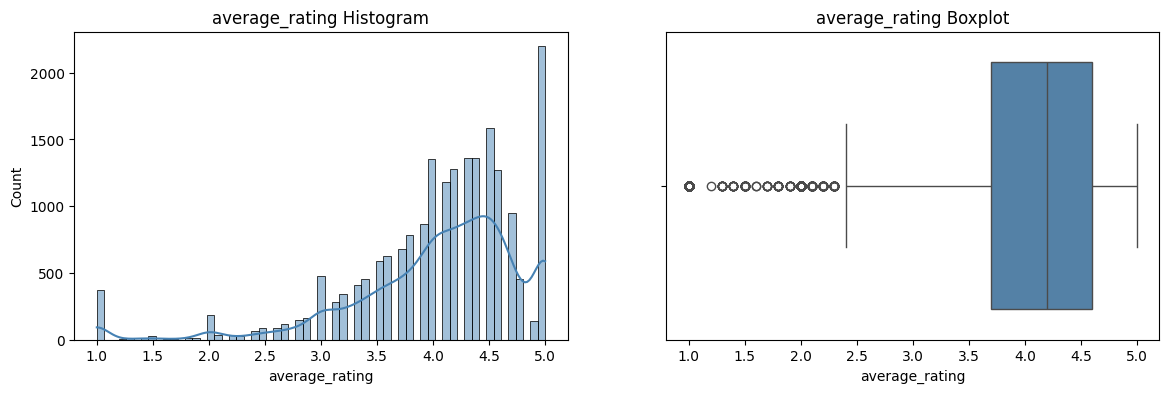

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['average_rating']

# Histogramas
for col in num_cols:

  fig, ax = plt.subplots(1, 2, figsize=(14, 4))

  sns.histplot(data=metadata_df, x=col, ax=ax[0], color="steelblue", kde=True)
  ax[0].title.set_text(f"{col} Histogram")

  sns.boxplot(data=metadata_df, x=col, ax=ax[1], color="steelblue")
  ax[1].title.set_text(f"{col} Boxplot")

  plt.show()

**Merged Datasets**

In [ ]:
# 1. Group the reviews by 'parent_asin' and count the number of rows (reviews) for each
# .size() counts the rows, and reset_index(name='review_count') turns it back into a clean DataFrame
review_counts = metadata_dr.groupby('parent_asin').size().reset_index(name='review_count')

# 2. Merge this new count DataFrame with your main products dataset
# We use 'left' to keep all products, even those with 0 reviews
products_with_counts = pd.merge(
    metadata_df,
    review_counts,
    on='parent_asin',
    how='left'
)

# 3. Handle the "0 reviews" scenario we discussed
# If a product had no reviews, the count will be NaN. We fill it with 0 and convert to integer.
products_with_counts['review_count'] = products_with_counts['review_count'].fillna(0).astype(int)

# 4. Sort the dataset to see the most reviewed products at the top
top_reviewed_products = products_with_counts.sort_values(by='review_count', ascending=False)

# 5. Display the results clearly
print("--- Products by Review Count ---")
display(top_reviewed_products[['title', 'parent_asin', 'review_count']].head(25))

--- Products by Review Count ---


,title,parent_asin,review_count
4901,Schmidt's Aluminum Free Natural Deodorant for ...,B09NFFSC5M,7
9651,KoluaWax Premium Waxing Kit for Women - Hot Me...,B0BJWB2Q9L,4
10402,essence | Lash Princess Sculpted Volume Mascar...,B06WW9SJ5M,4
16133,Gelish Fantastic Four Essentials Collection So...,B09BK6WVTC,3
6043,Pacifica Beauty Color Quench Lip Tint - Coconu...,B09BSCGSMJ,3
8874,KOTAMU Digital Wax Warmer Kit for Hair Removal...,B09KTPL1F3,3
5832,Wahl Self Cut Compact Corded Clipper Personal ...,B07994GT2W,3
3318,Olay Quench Body Lotion Ultra Moisture with Sh...,B001G7PLZ0,3
4746,Dove Hypoallergenic Body Wash To Moisturize Se...,B08373D96S,3
9852,"Olay Daily Facials for Clean Sensitive Skin, M...",B07SK34WDR,3


**Null prices filter**

In [ ]:
# 1. Group the reviews by 'parent_asin' and count the number of rows (reviews) for each
# .size() counts the rows, and reset_index(name='review_count') turns it back into a clean DataFrame
review_counts = metadata_dr.groupby('parent_asin').size().reset_index(name='review_count')

# 2. Merge this new count DataFrame with your main products dataset
# We use 'left' to keep all products, even those with 0 reviews
products_with_counts = pd.merge(
    metadata_df,
    review_counts,
    on='parent_asin',
    how='left'
)

# 3. Handle the "0 reviews" scenario we discussed
# If a product had no reviews, the count will be NaN. We fill it with 0 and convert to integer.
products_with_counts['review_count'] = products_with_counts['review_count'].fillna(0).astype(int)

# 4. Sort the dataset to see the most reviewed products at the top
top_reviewed_products = products_with_counts.sort_values(by='review_count', ascending=False)

# 5. Display the results clearly
print("--- Products by Review Count ---")
display(top_reviewed_products[['title', 'parent_asin', 'review_count']].head(20))

--- Products by Review Count ---


,title,parent_asin,review_count
4901,Schmidt's Aluminum Free Natural Deodorant for ...,B09NFFSC5M,7
9651,KoluaWax Premium Waxing Kit for Women - Hot Me...,B0BJWB2Q9L,4
10402,essence | Lash Princess Sculpted Volume Mascar...,B06WW9SJ5M,4
16133,Gelish Fantastic Four Essentials Collection So...,B09BK6WVTC,3
6043,Pacifica Beauty Color Quench Lip Tint - Coconu...,B09BSCGSMJ,3
8874,KOTAMU Digital Wax Warmer Kit for Hair Removal...,B09KTPL1F3,3
5832,Wahl Self Cut Compact Corded Clipper Personal ...,B07994GT2W,3
3318,Olay Quench Body Lotion Ultra Moisture with Sh...,B001G7PLZ0,3
4746,Dove Hypoallergenic Body Wash To Moisturize Se...,B08373D96S,3
9852,"Olay Daily Facials for Clean Sensitive Skin, M...",B07SK34WDR,3


**Filter the entire dataset by null price**

In [ ]:
import pandas as pd

# 1. Path to the FULL dataset (the 1M+ records file)
full_dataset_path = "/content/drive/MyDrive/ADSB Project/meta_Beauty_and_Personal_Care.jsonl"

# List to store the filtered chunks temporarily
filtered_chunks = []

print("Processing the entire dataset in chunks. This might take a couple of minutes...")

# 2. Read the massive file in chunks of 100,000 lines to prevent RAM crashes
for chunk in pd.read_json(full_dataset_path, lines=True, chunksize=100000):

    # 3. THE CRITICAL FILTER: Drop rows where 'price' is NaN (null)
    # This guarantees we only keep products that have a price tag.
    clean_chunk = chunk.dropna(subset=['price'])

    # Append the cleaned chunk to our list
    filtered_chunks.append(clean_chunk)

# 4. Concatenate all the clean chunks back together into one master DataFrame
full_clean_df = pd.concat(filtered_chunks, ignore_index=True)

# 5. Display the final architecture
print("\n--- Final Dataset Architecture ---")
print(f"Success! Total records with a valid price: {full_clean_df.shape[0]:,}")

# Optional: Clean the price strings to numeric float values right away
full_clean_df['numeric_price'] = full_clean_df['price'].astype(str).str.extract(r'(\d+\.\d+|\d+)').astype(float)
full_clean_df = full_clean_df.dropna(subset=['numeric_price'])

print(f"Total records ready for mathematical modeling: {full_clean_df.shape[0]:,}")

Processing the entire dataset in chunks. This might take a couple of minutes...

--- Final Dataset Architecture ---
Success! Total records with a valid price: 380,680
Total records ready for mathematical modeling: 380,618


**Merged filtered datasets**

In [ ]:
# Copy the 10GB file from Google Drive network to the local SSD of the virtual machine
!rsync -ah --progress "/content/drive/MyDrive/ADSB Project/Beauty_and_Personal_Care.jsonl" "/content/Beauty_Local.jsonl"

sending incremental file list
Beauty_and_Personal_Care.jsonl
         11.02G 100%   54.47MB/s    0:03:12 (xfr#1, to-chk=0/1)


In [ ]:
import pandas as pd
import time

# 1. Local paths and variables setup
local_reviews_path = "/content/Beauty_Local.jsonl"
cumulative_counts = pd.Series(dtype=int)

print("Starting massive scan from local SSD...")
start_time = time.time()
chunk_number = 1

# 2. Process the 11GB file in chunks
for chunk in pd.read_json(local_reviews_path, lines=True, chunksize=250000):
    print(f"Processing chunk {chunk_number} ({(chunk_number * 250000):,} reviews scanned)...")

    # Count the occurrences of parent_asin in this specific chunk
    chunk_counts = chunk['parent_asin'].value_counts()

    # Add to the cumulative total
    cumulative_counts = cumulative_counts.add(chunk_counts, fill_value=0)
    chunk_number += 1

# 3. Format the final count into a clean DataFrame
review_counts_df = cumulative_counts.reset_index()
review_counts_df.columns = ['parent_asin', 'review_count']

end_time = time.time()
print(f"\nMassive count finished in {round((end_time - start_time) / 60, 2)} minutes!")
print(f"Total unique products found in reviews: {review_counts_df.shape[0]:,}")

# 4. Merge with the cleaned product dataset (full_clean_df)
print("\nMerging databases...")
final_dashboard_df = pd.merge(
    full_clean_df,
    review_counts_df,
    on='parent_asin',
    how='left'
)

# 5. Handle products with 0 reviews
final_dashboard_df['review_count'] = final_dashboard_df['review_count'].fillna(0).astype(int)

# 6. Apply the Popularity Threshold (Keep products with >= 50 reviews for the NLP model)
threshold = 50
master_dataset = final_dashboard_df[final_dashboard_df['review_count'] >= threshold].copy()

# 7. Sort by review count to see the market leaders
master_dataset = master_dataset.sort_values(by='review_count', ascending=False)

print(f"\n--- Final Master Dataset (Products with >= {threshold} reviews) ---")
print(f"Total products retained for the model: {master_dataset.shape[0]:,}")
display(master_dataset[['title', 'parent_asin', 'numeric_price', 'review_count']].head(10))

# 8. Save the master dataset to Google Drive for the Data Science phase
output_master_path = "/content/drive/MyDrive/ADSB Project/Master_Beauty_Dataset.csv"
master_dataset.to_csv(output_master_path, index=False)
print(f"\nMaster dataset successfully saved to: {output_master_path}")

Starting massive scan from local SSD...
Processing chunk 1 (250,000 reviews scanned)...
Processing chunk 2 (500,000 reviews scanned)...
Processing chunk 3 (750,000 reviews scanned)...
Processing chunk 4 (1,000,000 reviews scanned)...
Processing chunk 5 (1,250,000 reviews scanned)...
Processing chunk 6 (1,500,000 reviews scanned)...
Processing chunk 7 (1,750,000 reviews scanned)...
Processing chunk 8 (2,000,000 reviews scanned)...
Processing chunk 9 (2,250,000 reviews scanned)...
Processing chunk 10 (2,500,000 reviews scanned)...
Processing chunk 11 (2,750,000 reviews scanned)...
Processing chunk 12 (3,000,000 reviews scanned)...
Processing chunk 13 (3,250,000 reviews scanned)...
Processing chunk 14 (3,500,000 reviews scanned)...
Processing chunk 15 (3,750,000 reviews scanned)...
Processing chunk 16 (4,000,000 reviews scanned)...
Processing chunk 17 (4,250,000 reviews scanned)...
Processing chunk 18 (4,500,000 reviews scanned)...
Processing chunk 19 (4,750,000 reviews scanned)...
Proces

,title,parent_asin,numeric_price,review_count
301435,REVLON One-Step Volumizer Original 1.0 Hair Dr...,B01LSUQSB0,38.80,37185
237061,essence | Lash Princess False Lash Effect Masc...,B0BVGHXZJ1,4.99,34162
264436,HSI Professional Glider Ceramic Flat Iron Hair...,B001MA0QY2,41.61,27605
37711,"Dr. Squatch All Natural Bar Soap for Men, 5 Ba...",B0BYBCFHTB,43.95,24342
94226,TruSkin Vitamin C Serum for Face – Anti Aging ...,B0BS71PXPX,21.97,22567
3777,HEMPZ Body Lotion - Grapefruit & Raspberry Crè...,B00HFG0FAM,16.00,16502
2654,ILNP Playdate - Vivid Magenta Holographic Jell...,B0B6QVGZ4X,10.00,16163
209075,"Pronexa Hairgenics Lavish Lash (3ml, 3 Month S...",B01MQS7GFT,24.99,14451
97040,"Arishine Magnetic Eyelashes Natural Look, Magn...",B0C777X1L4,19.97,14108
3587,Crave Naturals Glide Thru Detangling Brush for...,B0BHF9BF6Z,15.99,13977



Master dataset successfully saved to: /content/drive/MyDrive/ADSB Project/Master_Beauty_Dataset.csv


**Filtering only products with a main_category**

In [ ]:
import pandas as pd

# Load the CSV if you are starting a new session (uncomment the line below if needed)
master_dataset = pd.read_csv("/content/drive/MyDrive/ADSB Project/Master_Beauty_Dataset.csv")

print(f"Records before cleaning categories: {master_dataset.shape[0]:,}")

# 1. Drop true mathematical nulls (NaN) in the main_category column
clean_cat_df = master_dataset.dropna(subset=['main_category']).copy()

# 2. Drop empty strings or strings that only contain spaces (e.g., "", "   ")
# .astype(str) ensures we treat it as text, .str.strip() removes invisible spaces
clean_cat_df = clean_cat_df[clean_cat_df['main_category'].astype(str).str.strip() != '']

# Display the cleanup results
records_removed = master_dataset.shape[0] - clean_cat_df.shape[0]
print(f"Records removed (null or empty category): {records_removed:,}")
print(f"Total records perfectly clean: {clean_cat_df.shape[0]:,}")

# 3. Overwrite the Master CSV with this final, pristine version
output_master_path = "/content/drive/MyDrive/ADSB Project/Master_Beauty_Dataset.csv"
clean_cat_df.to_csv(output_master_path, index=False)
print("\nMaster dataset updated and saved successfully!")

/tmp/ipykernel_933/840250157.py:4: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  master_dataset = pd.read_csv("/content/drive/MyDrive/ADSB Project/Master_Beauty_Dataset.csv")


Records before cleaning categories: 48,684
Records removed (null or empty category): 929
Total records perfectly clean: 47,755

Master dataset updated and saved successfully!


**Deleting columns bought_together, subtitle and author, as they don't have any value for any row**

In [ ]:
import pandas as pd

# 1. Load the dataset (Uncomment if starting a new session)
master_dataset = pd.read_csv("/content/drive/MyDrive/ADSB Project/Master_Beauty_Dataset.csv")

print(f"Columns before dropping: {len(master_dataset.columns)}")

# 2. Define the list of completely empty columns to remove
columns_to_drop = ['bought_together', 'subtitle', 'author']

# 3. Drop the columns from the DataFrame
# axis=1 tells Pandas to look for columns, not rows
master_dataset = master_dataset.drop(columns=columns_to_drop, errors='ignore')

print(f"Columns after dropping: {len(master_dataset.columns)}")
print("Successfully removed 'bought_together', 'subtitle', and 'author'.")

# 4. Save the pristine dataset back to Google Drive, overwriting the previous version
output_master_path = "/content/drive/MyDrive/ADSB Project/Master_Beauty_Dataset.csv"
master_dataset.to_csv(output_master_path, index=False)

print("\nFinal Master CSV updated and saved successfully!")

/tmp/ipykernel_933/1666196328.py:4: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  master_dataset = pd.read_csv("/content/drive/MyDrive/ADSB Project/Master_Beauty_Dataset.csv")


Columns before dropping: 18
Columns after dropping: 15
Successfully removed 'bought_together', 'subtitle', and 'author'.

Final Master CSV updated and saved successfully!


**Filtered reviews**

In [ ]:
!rsync -ah --progress "/content/drive/MyDrive/ADSB Project/Beauty_and_Personal_Care.jsonl" "/content/Beauty_Local.jsonl"

sending incremental file list
Beauty_and_Personal_Care.jsonl
         11.02G 100%   53.08MB/s    0:03:18 (xfr#1, to-chk=0/1)


In [ ]:
import pandas as pd
import time
import os
import shutil

# 1. Load the products dataset to get the valid parent_asins
products_path = "/content/drive/MyDrive/ADSB Project/Master_Beauty_Dataset.csv"
master_products_df = pd.read_csv(products_path)

# Using a set is critical: O(1) lookup speed instead of O(N) list search
valid_asins = set(master_products_df['parent_asin'].unique())
print(f"Loaded {len(valid_asins):,} valid parent_asins from the master product catalog.")

# 2. Setup paths for processing
local_reviews_path = "/content/Beauty_Local.jsonl"
local_output_path = "/content/Master_Reviews_Local.csv"
drive_output_path = "/content/drive/MyDrive/ADSB Project/Master_Reviews_Dataset.csv"

# Clean up any leftover file from previous failed attempts to start fresh
if os.path.exists(local_output_path):
    os.remove(local_output_path)
    print("Cleaned up previous local temporary file.")

print("\nStarting memory-efficient filtering (Streaming directly to local SSD)...")
start_time = time.time()
chunk_number = 1
total_reviews_processed = 0
total_reviews_retained = 0

# 3. Read the massive local file in safe, smaller chunks of 250,000 lines
for chunk in pd.read_json(local_reviews_path, lines=True, chunksize=250000):
    total_reviews_processed += len(chunk)

    # Filter this chunk on the fly
    clean_chunk = chunk[chunk['parent_asin'].isin(valid_asins)]

    # Write the filtered data directly to the local SSD in append mode ('a')
    if not clean_chunk.empty:
        total_reviews_retained += len(clean_chunk)

        # Write header only for the very first block, then append without headers
        is_first_write = not os.path.exists(local_output_path)
        clean_chunk.to_csv(local_output_path, mode='a', index=False, header=is_first_write)

    # Python immediately frees the memory of this chunk before the next iteration
    print(f"Processed chunk {chunk_number} ({total_reviews_processed:,} reviews scanned). Retained & written: {total_reviews_retained:,}")
    chunk_number += 1

# 4. Copy the complete, healthy master file to Google Drive in a single operations
print("\nStream finished! Copying the final clean CSV to your Google Drive...")
shutil.copy(local_output_path, drive_output_path)

end_time = time.time()
print(f"\nFiltering complete in {round((end_time - start_time) / 60, 2)} minutes!")
print(f"Total reviews scanned: {total_reviews_processed:,}")
print(f"Total reviews retained: {total_reviews_retained:,}")
print(f"Master reviews dataset successfully saved to Google Drive: {drive_output_path}")

Loaded 47,755 valid parent_asins from the master product catalog.

Starting memory-efficient filtering (Streaming directly to local SSD)...
Processed chunk 1 (250,000 reviews scanned). Retained & written: 126,044
Processed chunk 2 (500,000 reviews scanned). Retained & written: 267,697
Processed chunk 3 (750,000 reviews scanned). Retained & written: 410,759
Processed chunk 4 (1,000,000 reviews scanned). Retained & written: 553,521
Processed chunk 5 (1,250,000 reviews scanned). Retained & written: 700,923
Processed chunk 6 (1,500,000 reviews scanned). Retained & written: 849,018
Processed chunk 7 (1,750,000 reviews scanned). Retained & written: 999,253
Processed chunk 8 (2,000,000 reviews scanned). Retained & written: 1,140,947
Processed chunk 9 (2,250,000 reviews scanned). Retained & written: 1,285,631
Processed chunk 10 (2,500,000 reviews scanned). Retained & written: 1,427,905
Processed chunk 11 (2,750,000 reviews scanned). Retained & written: 1,574,656
Processed chunk 12 (3,000,000 r

**Columns inspection**

In [ ]:
import pandas as pd

products_path = "/content/drive/MyDrive/ADSB Project/Master_Beauty_Dataset.csv"
reviews_path = "/content/drive/MyDrive/ADSB Project/Master_Reviews_Dataset.csv"

print("--- INSPECCIÓN DEL DATASET DE PRODUCTOS ---")
# Leemos solo 5 filas para ver la estructura
prod_preview = pd.read_csv(products_path, nrows=5)
print("\nColumnas detectadas:")
print(prod_preview.columns.tolist())
print("\nTipos de datos asignados por Pandas:")
print(prod_preview.dtypes)

print("\n" + "="*50 + "\n")

print("--- INSPECCIÓN DEL DATASET DE RESEÑAS ---")
rev_preview = pd.read_csv(reviews_path, nrows=5)
print("\nColumnas detectadas:")
print(rev_preview.columns.tolist())
print("\nTipos de datos asignados por Pandas:")
print(rev_preview.dtypes)

--- INSPECCIÓN DEL DATASET DE PRODUCTOS ---

Columnas detectadas:
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'numeric_price', 'review_count']

Tipos de datos asignados por Pandas:
main_category      object
title              object
average_rating    float64
rating_number       int64
features           object
description        object
price             float64
images             object
videos             object
store              object
categories         object
details            object
parent_asin        object
numeric_price     float64
review_count        int64
dtype: object


--- INSPECCIÓN DEL DATASET DE RESEÑAS ---

Columnas detectadas:
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Tipos de datos asignados por Pandas:
rating                int64
title                object
text      

## Database C - Most helpful reviews and keywords

This section continues the existing pipeline without changing `Master_Beauty_Dataset.csv` or `Master_Reviews_Dataset.csv`. It creates a frontend-ready subset with the most helpful reviews for every product and a compact product-level summary.

Outputs:
- `Master_Reviews_Dataset_Subset.csv`: one row per selected review.
- `Master_Reviews_Dataset_Subset.jsonl`: the same rows in API-friendly JSON Lines format.
- `Master_Product_Review_Summary.csv`: one row per product with aggregated keywords and review metrics.


In [ ]:
import os
import time
import numpy as np
import pandas as pd

# Configuration: keep this small for a fast frontend response.
TOP_K_REVIEWS_PER_PRODUCT = 5
CSV_CHUNK_SIZE = 250_000
KEYWORDS_PER_REVIEW = 8

project_dir = "/content/drive/MyDrive/ADSB Project"
products_path = os.path.join(project_dir, "Master_Beauty_Dataset.csv")
reviews_path = os.path.join(project_dir, "Master_Reviews_Dataset.csv")
subset_csv_path = os.path.join(project_dir, "Master_Reviews_Dataset_Subset.csv")
subset_jsonl_path = os.path.join(project_dir, "Master_Reviews_Dataset_Subset.jsonl")
summary_csv_path = os.path.join(project_dir, "Master_Product_Review_Summary.csv")

required_review_columns = [
    "rating", "title", "text", "asin", "parent_asin",
    "user_id", "timestamp", "helpful_vote", "verified_purchase"
]

review_columns = pd.read_csv(reviews_path, nrows=0).columns.tolist()
missing_columns = sorted(set(required_review_columns) - set(review_columns))
if missing_columns:
    raise ValueError(f"Master_Reviews_Dataset is missing required columns: {missing_columns}")

print(f"Selecting the top {TOP_K_REVIEWS_PER_PRODUCT} helpful reviews per product...")
start_time = time.time()
top_candidates = pd.DataFrame()
reviews_scanned = 0

for chunk_number, chunk in enumerate(
    pd.read_csv(reviews_path, usecols=required_review_columns, chunksize=CSV_CHUNK_SIZE),
    start=1,
):
    reviews_scanned += len(chunk)

    chunk["parent_asin"] = chunk["parent_asin"].fillna("").astype(str).str.strip()
    chunk["review_title"] = chunk["title"].fillna("").astype(str).str.strip()
    chunk["review_text"] = chunk["text"].fillna("").astype(str).str.strip()
    chunk["helpful_vote"] = pd.to_numeric(chunk["helpful_vote"], errors="coerce").fillna(0).clip(lower=0).astype("int64")
    chunk["rating"] = pd.to_numeric(chunk["rating"], errors="coerce")
    chunk["verified_purchase"] = (
        chunk["verified_purchase"].astype(str).str.lower().map({"true": True, "false": False}).fillna(False)
    )
    chunk["timestamp_sort"] = pd.to_datetime(chunk["timestamp"], errors="coerce", utc=True)

    # Empty reviews cannot provide useful frontend content or keywords.
    chunk = chunk[(chunk["parent_asin"] != "") & (chunk["review_text"] != "")].copy()
    chunk = chunk.drop_duplicates(
        subset=["parent_asin", "user_id", "timestamp", "review_text"]
    )

    # Helpful votes define relevance. Verified and recent reviews break ties.
    chunk_best = (
        chunk.sort_values(
            ["parent_asin", "helpful_vote", "verified_purchase", "timestamp_sort"],
            ascending=[True, False, False, False],
            kind="mergesort",
        )
        .groupby("parent_asin", sort=False)
        .head(TOP_K_REVIEWS_PER_PRODUCT)
    )

    top_candidates = pd.concat([top_candidates, chunk_best], ignore_index=True)
    top_candidates = (
        top_candidates.sort_values(
            ["parent_asin", "helpful_vote", "verified_purchase", "timestamp_sort"],
            ascending=[True, False, False, False],
            kind="mergesort",
        )
        .groupby("parent_asin", sort=False)
        .head(TOP_K_REVIEWS_PER_PRODUCT)
        .reset_index(drop=True)
    )

    print(
        f"Chunk {chunk_number}: {reviews_scanned:,} reviews scanned; "
        f"{len(top_candidates):,} candidates retained."
    )

top_candidates = top_candidates.sort_values(
    ["parent_asin", "helpful_vote", "verified_purchase", "timestamp_sort"],
    ascending=[True, False, False, False],
    kind="mergesort",
).reset_index(drop=True)
top_candidates["review_rank"] = top_candidates.groupby("parent_asin").cumcount() + 1

print(
    f"Selection completed in {(time.time() - start_time) / 60:.2f} minutes. "
    f"Retained {len(top_candidates):,} reviews for "
    f"{top_candidates['parent_asin'].nunique():,} products."
)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF is lightweight, reproducible, and adequate for MVP keywords.
keyword_source = (
    top_candidates["review_title"].fillna("")
    + " "
    + top_candidates["review_text"].fillna("")
).str.replace(r"\s+", " ", regex=True).str.strip()

if keyword_source.empty:
    raise ValueError("No valid review text was found for keyword extraction.")

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=10_000,
    strip_accents="unicode",
)
tfidf_matrix = vectorizer.fit_transform(keyword_source)
feature_names = vectorizer.get_feature_names_out()

def extract_top_keywords(row_index, limit=KEYWORDS_PER_REVIEW):
    row = tfidf_matrix.getrow(row_index)
    if row.nnz == 0:
        return ""
    local_positions = np.argsort(row.data)[-limit:][::-1]
    return " | ".join(feature_names[row.indices[local_positions]])

top_candidates["keywords"] = [
    extract_top_keywords(i) for i in range(tfidf_matrix.shape[0])
]
print("Keywords created successfully.")


In [ ]:
from collections import Counter

product_columns = [
    "parent_asin", "title", "main_category", "numeric_price",
    "average_rating", "review_count"
]
products_for_frontend = pd.read_csv(products_path, usecols=product_columns)
products_for_frontend = products_for_frontend.rename(columns={"title": "product_title"})

frontend_reviews = top_candidates.merge(
    products_for_frontend, on="parent_asin", how="left", validate="many_to_one"
)
frontend_reviews["timestamp"] = frontend_reviews["timestamp_sort"].dt.strftime("%Y-%m-%dT%H:%M:%SZ")

# Do not expose reviewer identifiers in the frontend artifact.
frontend_columns = [
    "parent_asin", "asin", "product_title", "main_category",
    "numeric_price", "average_rating", "review_count",
    "review_rank", "rating", "review_title", "review_text",
    "helpful_vote", "verified_purchase", "timestamp", "keywords"
]
frontend_reviews = frontend_reviews[frontend_columns].sort_values(
    ["parent_asin", "review_rank"]
).reset_index(drop=True)

def aggregate_keywords(keyword_series, limit=15):
    terms = []
    for value in keyword_series.dropna():
        terms.extend(term.strip() for term in value.split("|") if term.strip())
    return " | ".join(term for term, _ in Counter(terms).most_common(limit))

product_review_summary = (
    frontend_reviews.groupby("parent_asin", as_index=False)
    .agg(
        selected_review_count=("review_rank", "count"),
        selected_helpful_votes=("helpful_vote", "sum"),
        selected_average_rating=("rating", "mean"),
        verified_review_share=("verified_purchase", "mean"),
        product_keywords=("keywords", aggregate_keywords),
    )
    .merge(products_for_frontend, on="parent_asin", how="left", validate="one_to_one")
)
product_review_summary["selected_average_rating"] = product_review_summary["selected_average_rating"].round(2)
product_review_summary["verified_review_share"] = product_review_summary["verified_review_share"].round(4)

frontend_reviews.to_csv(subset_csv_path, index=False)
frontend_reviews.to_json(subset_jsonl_path, orient="records", lines=True, force_ascii=False)
product_review_summary.to_csv(summary_csv_path, index=False)

print(f"Review subset saved to: {subset_csv_path}")
print(f"API-friendly review subset saved to: {subset_jsonl_path}")
print(f"Product review summary saved to: {summary_csv_path}")
display(frontend_reviews.head(10))


In [ ]:
# Final validation: these checks fail early if the frontend artifact is inconsistent.
assert frontend_reviews["parent_asin"].notna().all()
assert frontend_reviews["review_text"].str.strip().ne("").all()
assert frontend_reviews["review_rank"].between(1, TOP_K_REVIEWS_PER_PRODUCT).all()
assert frontend_reviews.groupby("parent_asin").size().le(TOP_K_REVIEWS_PER_PRODUCT).all()
assert not frontend_reviews.duplicated(["parent_asin", "review_rank"]).any()
assert frontend_reviews["helpful_vote"].ge(0).all()

print("Database C validation passed.")
print(f"Products available to the frontend: {frontend_reviews['parent_asin'].nunique():,}")
print(f"Reviews available to the frontend: {len(frontend_reviews):,}")
print(f"Maximum reviews per product: {frontend_reviews.groupby('parent_asin').size().max()}")
